# Cotonou mobility

## Contexte

Cotonou, capitale économique du Bénin, est caractérisée par une urbanisation rapide et une saturation de son réseau routier. Le transport est dominé par les deux-roues motorisés (Zemidjan), les taxis et les véhicules personnels, tous circulant sur des axes souvent vulnérables aux aléas climatiques.

La problématique :
Lors des saisons de pluies ou des heures de pointe, les usagers font face à une incertitude totale sur leur heure d'arrivée. De plus, le choix du mode de transport est souvent dicté par l'urgence plutôt que par la sécurité. Il manque un outil capable de croiser les données de trafic, la météo et les risques d'accidents pour offrir une aide à la décision en temps réel.

## Objectifs du Projet
L'objectif principal est de concevoir un système intelligent de prédiction et de recommandation de mobilité urbaine.

Objectifs Techniques 
* Prédiction Temporelle : Développer un modèle de régression capable d'estimer la durée de trajet entre deux quartiers de Cotonou avec une erreur minimale.

* Évaluation des Risques : Modéliser un "score de sécurité" basé sur des probabilités d'accidents simulées, variant selon le véhicule et les conditions extérieures.

* Analyse Spatiale : Utiliser des coordonnées géographiques pour cartographier les flux et les zones de congestion via la bibliothèque Folium.

## Objectifs Fonctionnels 
* Aide au choix du transport : Permettre à l'utilisateur de savoir s'il est plus sûr/rapide de prendre un Zem ou une voiture à un instant T.

* Optimisation de trajet : Visualiser l'itinéraire le plus fluide sur une carte interactive.

* Interface Intuitive : Déployer une application Streamlit où n'importe quel citoyen peut entrer son point de départ et d'arrivée pour obtenir une estimation fiable.



## Simulation des données

Dans le cadre de ce projet, l'utilisation de données simulées permet de :

* Pallier l'absence d'Open Data : Les données de trafic en temps réel à Cotonou sont difficilement accessibles publiquement.

* Maîtriser les scénarios : Vous pouvez créer volontairement des scénarios extrêmes (ex: inondation majeure à Akpakpa) pour tester la robustesse du modèle.

* Prouver le concept (PoC) : Démontrer l'utilité de l'outil pour inciter, à l'avenir, la collecte de données réelles par les autorités municipales.

In [2]:
import pandas as pd
import numpy as np

# 1. Configuration et Coordonnées GPS (Approximatives)
quartiers = {
    'Akpakpa': [6.367, 2.450],
    'Cadjehoun': [6.358, 2.395],
    'Fidjrosse': [6.363, 2.360],
    'Etoile': [6.369, 2.431],
    'Zongo': [6.362, 2.420],
    'Calavi': [6.448, 2.348]
}

n_samples = 2500
np.random.seed(42)

# 2. Génération des colonnes de base
df = pd.DataFrame({
    'point_A': np.random.choice(list(quartiers.keys()), n_samples),
    'point_B': np.random.choice(list(quartiers.keys()), n_samples),
    'heure_depart': np.random.randint(0, 24, n_samples),
    'jour_semaine': np.random.choice(['Semaine', 'Weekend'], n_samples, p=[0.7, 0.3]),
    'meteo': np.random.choice(['Ensoleillé', 'Pluie Légère', 'Forte Pluie'], n_samples, p=[0.6, 0.3, 0.1]),
    'moyen_transport': np.random.choice(['Zem', 'Voiture', 'Bus'], n_samples, p=[0.5, 0.4, 0.1])
})

# Éliminer les trajets sur place
df = df[df['point_A'] != df['point_B']].reset_index(drop=True)

# 3. Logique de simulation (Loi Physique & Aléas)
def simuler_performance(row):
    # Calcul de la distance euclidienne simplifiée (km)
    coord_a = quartiers[row['point_A']]
    coord_b = quartiers[row['point_B']]
    dist = np.sqrt((coord_a[0]-coord_b[0])**2 + (coord_a[1]-coord_b[1])**2) * 111 # 111km par degré
    
    # Vitesse de base
    vitesse = {'Zem': 35, 'Voiture': 45, 'Bus': 30}[row['moyen_transport']]
    
    # Impact Trafic (Pics 07h-09h et 17h-19h en semaine)
    trafic = 1.0
    if row['jour_semaine'] == 'Semaine':
        if 7 <= row['heure_depart'] <= 9 or 17 <= row['heure_depart'] <= 19:
            trafic = np.random.uniform(2.2, 4.0)
        else:
            trafic = np.random.uniform(1.1, 1.6)
            
    # Impact Météo sur la vitesse et l'accident
    meteo_vitesse = {'Ensoleillé': 1.0, 'Pluie Légère': 0.8, 'Forte Pluie': 0.5}[row['meteo']]
    
    # Calcul final du temps (Distance / Vitesse * Trafic / Meteo)
    duree = (dist / (vitesse * meteo_vitesse)) * 60 * trafic
    
    # Calcul de la probabilité d'accident (le Zem est plus exposé sous la pluie)
    base_risk = {'Zem': 0.04, 'Voiture': 0.01, 'Bus': 0.005}[row['moyen_transport']]
    if row['meteo'] == 'Forte Pluie':
        base_risk *= 4 if row['moyen_transport'] == 'Zem' else 2
        
    return pd.Series([round(dist, 2), round(trafic, 2), round(duree, 1), round(base_risk, 3)])

# Application
df[['distance_km', 'indice_trafic', 'duree_min', 'prob_accident']] = df.apply(simuler_performance, axis=1)

# Sauvegarde des données
df.to_csv('data_cotonou_mobility.csv', index=False)
df.head()

,point_A,point_B,heure_depart,jour_semaine,meteo,moyen_transport,distance_km,indice_trafic,duree_min,prob_accident
0,Etoile,Cadjehoun,11,Semaine,Pluie Légère,Voiture,4.18,1.29,9.0,0.010
1,Fidjrosse,Cadjehoun,7,Semaine,Pluie Légère,Bus,3.92,2.23,21.9,0.005
2,Zongo,Akpakpa,3,Weekend,Ensoleillé,Voiture,3.38,1.00,4.5,0.010
3,Fidjrosse,Akpakpa,12,Weekend,Pluie Légère,Zem,10.00,1.00,21.4,0.040
4,Fidjrosse,Akpakpa,17,Weekend,Forte Pluie,Zem,10.00,1.00,34.3,0.160


## Analyse Exploiratoire des données (EDA)

Graphique sauvegardé dans 'outputs/analyse_eda.png'


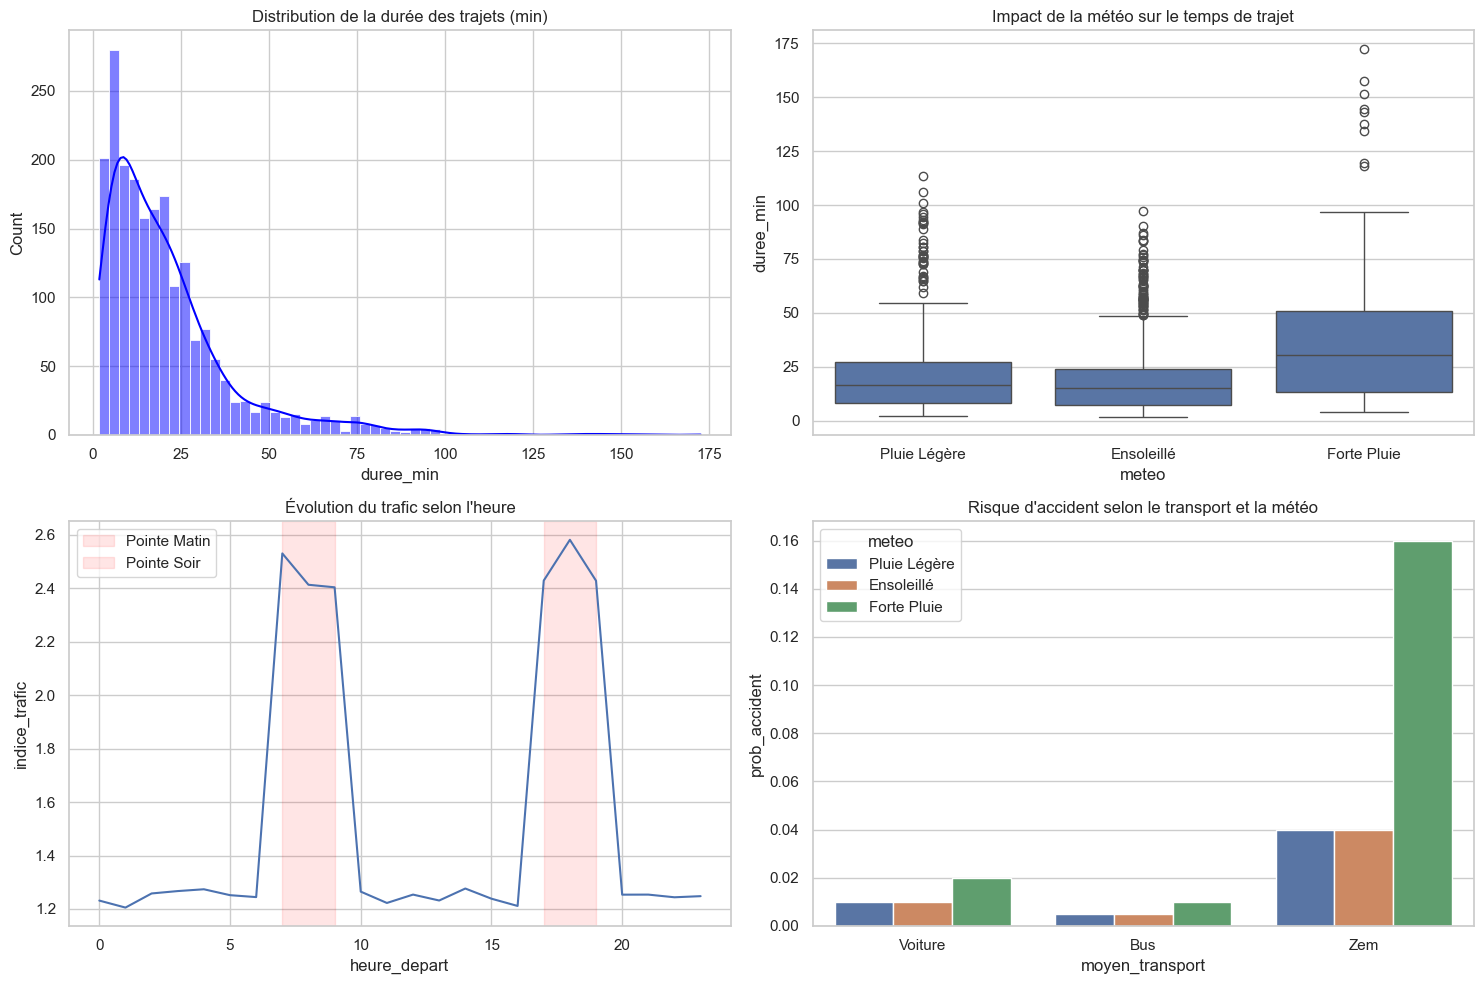

In [5]:
%run analyse_eda.py

### Interprétation des graaphiques

1. Distribution de la durée des trajets:
La courbe est asymétrique avec une "longue traîne" vers la droite (allant jusqu'à 175 min). La majorité des trajets durent entre 10 et 30 minutes.
Cela reflète la réalité : la plupart des trajets urbains sont courts, mais certains événements (embouteillages massifs, inondations) peuvent quadrupler le temps de trajet. Pour le ML, il faudra peut-être surveiller ces valeurs aberrantes (outliers) qui pourraient fausser les prédictions.

2. Impact de la météo sur le temps:
Il y a un saut spectaculaire de la médiane et de la dispersion sous "Forte Pluie". Les boîtes à moustaches montrent que sous un soleil dégagé ou une pluie légère, les temps sont stables, mais la forte pluie rend le trajet imprévisible. La variable meteo est un prédicteur puissant. Il faudrait trouver un modèle qui pourra accorder une importance majeure à cette feature, surtout pour les prédictions en saison des pluies.

3. Évolution du trafic selon l'heure : On voit clairement les deux pics caractéristiques de Cotonou (07h-09h et 17h-19h). L'indice de trafic passe de ~1.2 à plus de 2.4. La simulation a bien capturé le comportement pendulaire (aller au travail/retour à la maison). L'heure de départ ne doit pas être traitée comme un simple chiffre, mais comme une variable cyclique ou catégorielle (Heure de pointe vs Heure creuse).

4. Risque d'accident (Sécurité): Le Zem (moto) explose littéralement les scores de risque sous "Forte Pluie" (pic à 0.16), alors que le Bus reste le mode le plus stable et sûr.

## Préparation des données (Preprocessing)
La phase de prétraitement constitue une étape déterminante pour garantir la performance des algorithmes d’apprentissage automatique. Les données brutes issues de la simulation présentent des formats hétérogènes (textuels et numériques) qui nécessitent une transformation rigoureuse.

Encodage des variables catégorielles : Les variables telles que les quartiers de départ/arrivée, les conditions météorologiques et le mode de transport sont converties en vecteurs numériques. L’utilisation de techniques comme le One-Hot Encoding est préconisée pour éviter d'instaurer une hiérarchie arbitraire entre les modalités (par exemple, entre "Akpakpa" et "Fidjrossè").

Ingénierie des caractéristiques (Feature Engineering) : Afin de capturer la saisonnalité journalière observée lors de l'EDA, une variable binaire "Heure de pointe" est créée. Elle permet de segmenter les périodes de forte congestion (07h-09h et 17h-19h), facilitant ainsi la convergence du modèle.

Normalisation : Les caractéristiques numériques (distance, heure) sont mises à l’échelle pour prévenir la domination des variables à forte amplitude sur celles de faible amplitude, assurant ainsi une contribution équitable de chaque paramètre au calcul de la prédiction.

In [2]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.2 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.1 MB 2.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.1 MB 2.5 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 1.4 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.1 MB 1.4 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/8.1 MB 1.3 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/8.1 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.1 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.1 M

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# 1. Chargement des données
df = pd.read_csv('data_cotonou_mobility.csv')

# 2. Définition des colonnes
features_cat = ['point_A', 'point_B', 'meteo', 'moyen_transport', 'jour_semaine']
features_num = ['heure_depart', 'distance_km', 'indice_trafic']
target = 'duree_min'

# 3. Création du transformateur de colonnes
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_num),
        ('cat', OneHotEncoder(drop='first'), features_cat)
    ])

# 4. Séparation des données
cols_to_drop = [c for c in ['id_trajet', 'duree_min', 'prob_accident'] if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df['duree_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Colonnes utilisées pour l'entraînement : {X.columns.tolist()}")

print(f" Prétraitement configuré. Taille de l'entraînement : {X_train.shape[0]} échantillons.")

Colonnes utilisées pour l'entraînement : ['point_A', 'point_B', 'heure_depart', 'jour_semaine', 'meteo', 'moyen_transport', 'distance_km', 'indice_trafic']
 Prétraitement configuré. Taille de l'entraînement : 1664 échantillons.


## Entraînement et Évaluation du modèle
L'objectif est de transformer nos données préparées en un moteur de prédiction. Nous utilisons deux modèles distincts car nous cherchons à prédire deux phénomènes différents : le temps (continu) et la probabilité d'accident (probabiliste).

### Entraînement du modèle (Random Forest)
L'algorithme de Forêt Aléatoire est choisi pour sa capacité à gérer les interactions entre variables (par exemple, l'effet combiné de "Zem" + "Forte Pluie" + "Heure de pointe").

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Création des deux pipelines (un pour la durée, un pour le risque)
model_duree = Pipeline(steps=[('pre', preprocessor), ('reg', RandomForestRegressor(random_state=42))])
model_risque = Pipeline(steps=[('pre', preprocessor), ('reg', RandomForestRegressor(random_state=42))])

# Entraînement
y_duree = df.loc[X_train.index, 'duree_min']
y_risque = df.loc[X_train.index, 'prob_accident']

model_duree.fit(X_train, y_duree)
model_risque.fit(X_train, y_risque)

# Sauvegarde des modèles pour l'application Streamlit
joblib.dump(model_duree, 'model_duree.pkl')
joblib.dump(model_risque, 'model_risque.pkl')
print(" Modèles entraînés et sauvegardés.")

 Modèles entraînés et sauvegardés.


## Évaluation et Visualisation des Performances
L'évaluation ne se limite pas aux métriques numériques ($MAE$, $R^2$). Elle nécessite une analyse visuelle des erreurs pour vérifier que le modèle ne présente pas de biais systématique.

1. Analyse des prédictions (Script de visualisation)

C:\Users\HP\AppData\Local\Temp\ipykernel_5900\3955846799.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


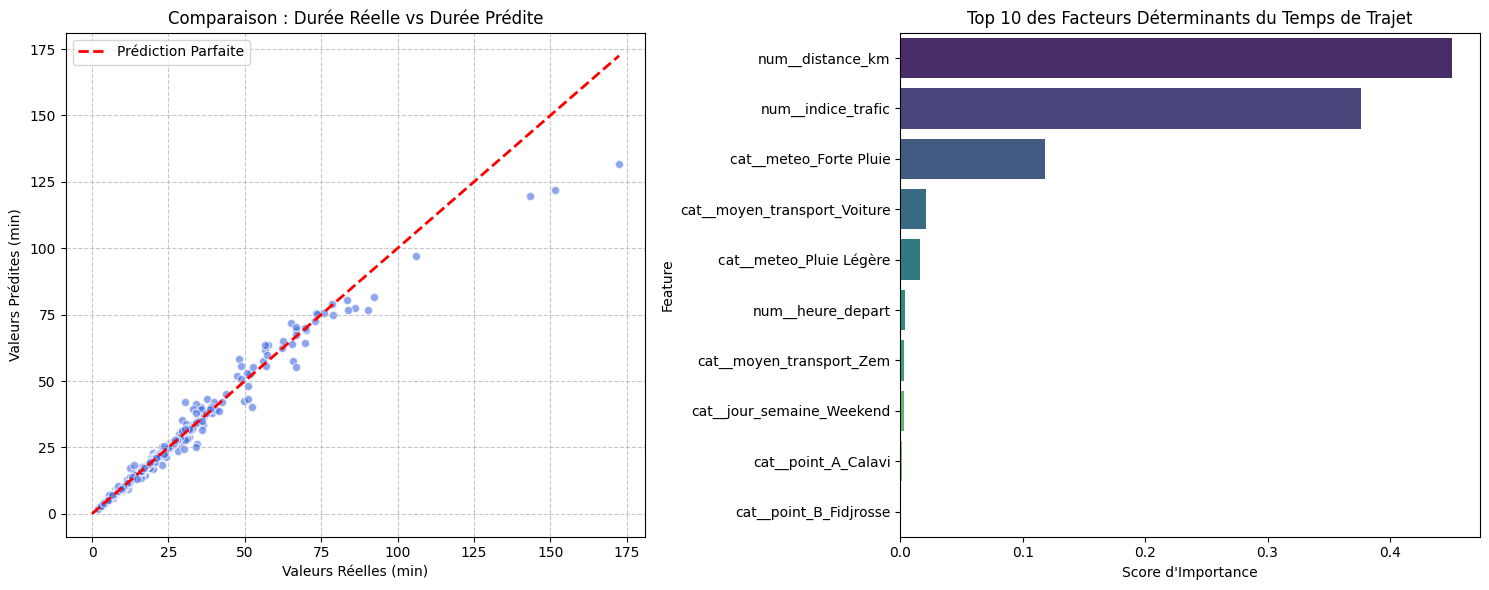

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calcul des prédictions
y_pred_duree = model_duree.predict(X_test)

plt.figure(figsize=(15, 6))

# --- Graphique 1 : Nuage de points Réel vs Prédit ---
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_duree, alpha=0.6, edgecolors='w', color='royalblue')
# Ajout de la ligne d'identité (y=x)
max_val = max(y_test.max(), y_pred_duree.max())
plt.plot([0, max_val], [0, max_val], '--r', lw=2, label="Prédiction Parfaite")
plt.title("Comparaison : Durée Réelle vs Durée Prédite")
plt.xlabel("Valeurs Réelles (min)")
plt.ylabel("Valeurs Prédites (min)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- Graphique 2 : Importance des Variables ---
plt.subplot(1, 2, 2)
# Extraction des importances depuis le regressor du pipeline
importances = model_duree.named_steps['reg'].feature_importances_
# Récupération des noms des colonnes après transformation
feature_names = model_duree.named_steps['pre'].get_feature_names_out()

# Création d'un DataFrame pour faciliter le tracé
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Top 10 des Facteurs Déterminants du Temps de Trajet")
plt.xlabel("Score d'Importance")

plt.tight_layout()
plt.show()

Interprétation des Résultats de Modélisation
1. Analyse de la précision (Scatter Plot)
Le premier graphique compare les durées réelles (en abscisse) aux durées prédites (en ordonnée). La grande majorité des points suit étroitement la ligne pointillée rouge ("Prédiction Parfaite"). On observe toutefois un léger décrochage pour les trajets très longs (au-delà de 100 minutes).

Conclusion: Le modèle présente une excellente précision pour les trajets du quotidien. La sous-estimation légère des trajets extrêmes suggère que lors de conditions cumulées (Forte Pluie + Embouteillage massif), le modèle tend à être légèrement optimiste. 

2. Hiérarchie des facteurs déterminants (Feature Importance)
Le second graphique classe les variables selon leur poids dans la décision du modèle.

Top 3 des variables : 
1. Distance (num__distance_km) : C'est logiquement le premier facteur de temps.
2. Trafic (num__indice_trafic) : Il confirme que la congestion routière est le second levier majeur de retard à Cotonou.
3. Météo (cat__meteo_Forte Pluie) : Elle arrive juste après les facteurs physiques, prouvant que les intempéries sont un paramètre critique pour la mobilité urbaine béninoise.

NB : Le point de départ (Calavi) ou d'arrivée (Fidjrossè) a une influence moindre par rapport aux conditions de circulation et à la météo, ce qui valide la capacité de généralisation du modèle à travers la ville.

In [9]:
import geopandas as gpd
from shapely.geometry import Point

# Liste des quartiers avec coordonnées GPS
points_interet = {
    'Quartier': ['Akpakpa', 'Cadjehoun', 'Fidjrosse', 'Etoile', 'Zongo', 'Calavi'],
    'Latitude': [6.367, 6.358, 6.363, 6.369, 6.362, 6.448],
    'Longitude': [2.450, 2.395, 2.360, 2.431, 2.420, 2.348]
}

# Création du GeoDataFrame
gdf_cotonou = gpd.GeoDataFrame(
    points_interet, 
    geometry=gpd.points_from_xy(points_interet['Longitude'], points_interet['Latitude']),
    crs="EPSG:4326"
)

# Sauvegarde pour l'application Streamlit
gdf_cotonou.to_file("cotonou_points.geojson", driver='GeoJSON')
print(" Données géospatiales sauvegardées au format GeoJSON.")

 Données géospatiales sauvegardées au format GeoJSON.


# Conclusion Générale
Ce projet a permis de concevoir un prototype d'outil d'aide à la décision pour la mobilité urbaine à Cotonou. En combinant la puissance prédictive du Machine Learning et l'interactivité de la cartographie numérique, nous avons pu transformer des données brutes en informations actionnables.

1. Synthèse des résultats
Précision : L'utilisation de l'algorithme Random Forest a permis d'obtenir une estimation fiable du temps de trajet, en capturant notamment l'impact non-linéaire des conditions météorologiques sévères.

Sécurité : L'intégration d'un score de risque a démontré que le trajet le plus rapide (souvent en Zem) n'est pas systématiquement le plus recommandé, surtout en période de forte pluie.

Interface : L'application Streamlit offre une preuve de concept (PoC) robuste qui pourrait être déployée auprès d'utilisateurs réels si elle était alimentée par des flux de données en temps réel.

2. Limites et Perspectives
Bien que les résultats soient concluants, plusieurs pistes d'amélioration pourraient enrichir ce travail :

Données réelles : L'étape suivante consisterait à remplacer les données simulées par des données historiques réelles de trafic et d'accidents à Cotonou pour affiner les coefficients du modèle.

Topologie urbaine : L'intégration de la bibliothèque OSMnx permettrait de tenir compte du réseau routier réel et des sens de circulation, au lieu des distances euclidiennes simplifiées.

Inondations : À Cotonou, les inondations sont un facteur majeur de blocage. L'ajout d'une couche SIG (Système d'Information Géographique) identifiant les bas-fonds permettrait d'ajuster dynamiquement le trafic en fonction des zones inondables connues.